# ImageNet Verification Results — Analysis by Coarse Semantic Clusters

This notebook reproduces the style of analysis in `some_rnd_imgs_diff_pert_diff_eps.ipynb`, but **adds a semantic grouping layer**:
we map each ImageNet image to its **WNID → human label → coarse category** (e.g., birds, dogs, vehicles), using the same WordNet-style
clustering logic from `clustering_imagenet.ipynb`.

**Inputs you need**
- `combined_results.csv` (or any results CSV with at least a `result` column and an `image` or `instance_id` column)
- `imagenet_class_index.json` (already provided in this workspace)

> Tip: keep this notebook next to your `results/<experiment>/combined_results.csv` so relative paths work.

In [73]:
# ============================
# 0) Config
# ============================
from pathlib import Path

# If you used the same structure as your other notebook:
experiment = "vggnet16_benchmark2022_segmented_all"
CSV_PATH = Path(f"../results/{experiment}/combined_results.csv")

# Class index (WNID -> label). Provided in this workspace.
IMAGENET_CLASS_INDEX_JSON = Path("imagenet_class_index.json")

# Choose which column identifies the image/instance.
# Common in your data: "image" (often a filename) and sometimes "instance_id".
IMAGE_COL_CANDIDATES = ["image", "instance_id"]

# Time columns used by your verifier outputs (adjust if needed).
TIME_COLS = ["bab_time", "all_time"]

CSV_PATH, IMAGENET_CLASS_INDEX_JSON

(PosixPath('../results/vggnet16_benchmark2022_segmented_all/combined_results.csv'),
 PosixPath('imagenet_class_index.json'))

In [74]:
# ============================
# 1) Load results
# ============================
import pandas as pd

assert CSV_PATH.exists(), f"CSV not found: {CSV_PATH.resolve()}"
df = pd.read_csv(CSV_PATH)

print("Rows:", len(df))
print("Columns:", list(df.columns)[:40], "..." if len(df.columns) > 40 else "")
df.head(3)

Rows: 10334
Columns: ['instance_id', 'image', 'tag', 'is_global', 'segment_index', 'eps', 'k', 'score', 'bbox', 'num_changed', 'num_fixed', 'total', 'percent_changed', 'pattern', 'onnx', 'vnnlib', 'timeout', 'result', 'lb_minus_rhs', 'domains_visited', 'bab_time', 'all_time', 'init_unstable'] 


,instance_id,image,tag,is_global,segment_index,eps,k,score,bbox,num_changed,...,pattern,onnx,vnnlib,timeout,result,lb_minus_rhs,domains_visited,bab_time,all_time,init_unstable
0,1,n01440764_tench,n01440764_tench_global,True,-1,0.0001,10,NaN,NaN,30,...,global,onnx/vgg16-7.onnx,vnnlib/n01440764_tench_global_k10_eps_0.0001.v...,1200.0,sat False,-inf,NaN,1.485778,2251.853036,0.0
1,2,n01440764_tench,n01440764_tench_global,True,-1,0.0001,50176,NaN,NaN,150528,...,global,onnx/vgg16-7.onnx,vnnlib/n01440764_tench_global_k50176_eps_0.000...,1200.0,sat True,NaN,NaN,NaN,2242.709431,0.0
2,3,n01440764_tench,n01440764_tench_global,True,-1,0.0003,10,NaN,NaN,30,...,global,onnx/vgg16-7.onnx,vnnlib/n01440764_tench_global_k10_eps_0.0003.v...,1200.0,sat False,-inf,NaN,2.445933,1859.241091,0.0


In [75]:
# ============================
# 2) Pick image id column
# ============================
def pick_first_existing(cols):
    for c in cols:
        if c in df.columns:
            return c
    return None

IMAGE_COL = pick_first_existing(IMAGE_COL_CANDIDATES)
assert IMAGE_COL is not None, f"Could not find any of {IMAGE_COL_CANDIDATES} in df.columns"

IMAGE_COL

'image'

In [76]:
# ============================
# 3) Normalize result labels (safe / unsafe / unknown)
# ============================
RESULT_COL = "result"
assert RESULT_COL in df.columns, "Expected a 'result' column in the CSV."

def canon_result(x: object) -> str:
    s = str(x).strip().lower()
    # Based on your recent runs: 'unsat False', 'timeout False', 'sat True'
    if "unsat" in s:
        return "safe"
    if "sat" in s:
        return "unsafe (counterexample)"
    if "timeout" in s:
        return "unknown (timeout)"
    return "other"

df["result_cat"] = df[RESULT_COL].map(canon_result)
df["result_cat"].value_counts(dropna=False)

result_cat
unknown (timeout)          5007
unsafe (counterexample)    3227
safe                       2015
other                        85
Name: count, dtype: int64

In [77]:
# ============================
# 4) Extract WNID from image/instance strings
# ============================
import re

WNID_RE = re.compile(r"(n\d{8})")

def extract_wnid(val: object) -> str | None:
    s = str(val)
    m = WNID_RE.search(s)
    return m.group(1) if m else None

df["wnid"] = df[IMAGE_COL].map(extract_wnid)

missing = df["wnid"].isna().mean()
print(f"WNID missing rate: {missing:.1%}")
df.loc[df["wnid"].isna(), [IMAGE_COL, RESULT_COL]].head(5)

WNID missing rate: 0.0%


,image,result


In [78]:
# ============================
# 5) Load ImageNet class index (WNID -> short label)
# ============================
import json

assert IMAGENET_CLASS_INDEX_JSON.exists(), f"Missing: {IMAGENET_CLASS_INDEX_JSON.resolve()}"

class_index = json.loads(IMAGENET_CLASS_INDEX_JSON.read_text(encoding="utf-8"))

wnid_to_label = {}
for _k, (wnid, label_str) in class_index.items():
    short = label_str.split(",")[0].strip()
    wnid_to_label[wnid] = short

df["label"] = df["wnid"].map(wnid_to_label)
df[["wnid", "label"]].dropna().drop_duplicates().head(10)

,wnid,label
0,n01440764,tench
12,n01443537,goldfish
24,n01484850,great_white_shark
36,n01491361,tiger_shark
48,n01496331,electric_ray
60,n01514668,cock
72,n01514859,hen
84,n01518878,ostrich
96,n01530575,brambling
108,n01531178,goldfinch


In [105]:
# ============================
# 6) Coarse category mapping via WordNet hypernyms + normalization/merging
# ============================
import pandas as pd
import nltk
from nltk.corpus import wordnet as wn

# Download WordNet data if missing (one-time per environment)
try:
    wn.synsets("dog")
except LookupError:
    nltk.download("wordnet")
    nltk.download("omw-1.4")

# --- Hypernym-based groups (your main buckets)
COARSE_GROUPS = {
    "birds":      ["bird.n.01"],
    "fish":       ["fish.n.01"],
    "reptiles":   ["reptile.n.01"],
    "amphibians": ["amphibian.n.01"],
    "insects":    ["insect.n.01", "arachnid.n.01"],
    "mammals":    ["mammal.n.01"],
    "plants":     ["plant.n.02", "flora.n.02"],
    "food":       ["food.n.01"],
    "vehicles":   ["vehicle.n.01"],
    "furniture":  ["furniture.n.01"],
    "clothing":   ["clothing.n.01", "garment.n.01"],
    "tools":      ["tool.n.01", "implement.n.01"],
    "instruments":["musical_instrument.n.01"],
}

# Priority order matters (more specific first, broad later)
COARSE_PRIORITY = [
    "birds","fish","reptiles","amphibians","insects",
    "vehicles","furniture","food","tools","instruments","clothing","plants",
    "mammals",
]

def wnid_to_wordnet_synset(wnid: str):
    # wnid like "n01443537" -> offset 1443537 noun synset
    offset = int(wnid[1:])
    return wn.synset_from_pos_and_offset("n", offset)

def synset_has_ancestor(synset, ancestor_name: str) -> bool:
    ancestor = wn.synset(ancestor_name)
    for s in synset.closure(lambda x: x.hypernyms()):
        if s == ancestor:
            return True
    return False

# --- Merge/normalize coarse labels so noun.* doesn't create duplicates
MERGE_COARSE = {
    # Merge WordNet lexnames into your chosen buckets
    "noun.plant": "plants",
    "noun.food": "food",

    # Optional: keep these as their own “leftover” buckets (clean names)
    "noun.animal": "animals",
    "noun.object": "objects",
    "noun.person": "people",
    "noun.communication": "communication",

    # You can keep noun.artifact as-is or rename:
    "noun.artifact": "artifacts",
    "noun.substance": "substances",
}

def normalize_coarse(coarse: str) -> str:
    s = str(coarse).strip().lower()

    # fix common typo seen in practice
    s = s.replace("noun.plan", "noun.plant")

    # map known lexnames / aliases to canonical buckets
    if s in MERGE_COARSE:
        return MERGE_COARSE[s]

    # light harmonization (in case anything sneaks in)
    if s == "plant": return "plants"
    if s == "vehicle": return "vehicles"

    return s

def coarse_category_for_wnid(wnid: str | None) -> str:
    if wnid is None or pd.isna(wnid):
        return "unknown"

    wnid = str(wnid).strip()
    try:
        syn = wnid_to_wordnet_synset(wnid)
    except Exception:
        return "unknown"

    # 1) Try your semantic buckets first
    for group in COARSE_PRIORITY:
        for anc in COARSE_GROUPS.get(group, []):
            if synset_has_ancestor(syn, anc):
                return group

    # 2) Otherwise fallback to WordNet lexname (noun.*)
    try:
        return normalize_coarse(syn.lexname())  # e.g., noun.artifact -> artifacts
    except Exception:
        return "unknown"

# Apply
df["coarse_cat"] = df["wnid"].map(coarse_category_for_wnid)

# Inspect
df["coarse_cat"].value_counts().head(30)

coarse_cat
artifacts        3228
mammals          2352
vehicles          732
birds             672
food              528
clothing          504
insects           372
animals           336
tools             302
reptiles          288
instruments       264
furniture         228
fish              168
noun.plantt       132
objects            96
communication      60
people             36
plants             24
substances         12
Name: count, dtype: int64

## A) Quick sanity checks

In [106]:
# How many unique ImageNet classes appear in this CSV?
n_unique_wnid = df["wnid"].nunique(dropna=True)
n_unique_labels = df["label"].nunique(dropna=True)
print("Unique WNIDs:", n_unique_wnid)
print("Unique labels:", n_unique_labels)

# Show a few examples per coarse category
ex = (df.dropna(subset=["wnid","label"])
        .drop_duplicates(subset=["wnid"])
        .groupby("coarse_cat")
        .head(5)[["coarse_cat","wnid","label"]]
     )
ex.sort_values(["coarse_cat","label"]).head(30)

Unique WNIDs: 861
Unique labels: 859


,coarse_cat,wnid,label
252,animals,n01629819,European_fire_salamander
288,animals,n01641577,bullfrog
264,animals,n01631663,eft
276,animals,n01632458,spotted_salamander
300,animals,n01644373,tree_frog
4188,artifacts,n02666196,abacus
4284,artifacts,n02699494,altar
4320,artifacts,n02708093,analog_clock
4332,artifacts,n02727426,apiary
4344,artifacts,n02749479,assault_rifle


## B) Outcome distribution by coarse category

In [107]:
# Counts and proportions
counts = (df.groupby(["coarse_cat", "result_cat"])
            .size()
            .rename("n")
            .reset_index())

totals = counts.groupby("coarse_cat")["n"].sum().rename("total").reset_index()
counts = counts.merge(totals, on="coarse_cat", how="left")
counts["pct"] = counts["n"] / counts["total"]

counts.sort_values(["coarse_cat","n"], ascending=[True, False]).head(20)

,coarse_cat,result_cat,n,total,pct
3,animals,unsafe (counterexample),204,336,0.607143
1,animals,safe,91,336,0.270833
2,animals,unknown (timeout),39,336,0.116071
0,animals,other,2,336,0.005952
6,artifacts,unknown (timeout),2253,3228,0.697955
7,artifacts,unsafe (counterexample),596,3228,0.184634
5,artifacts,safe,371,3228,0.114932
4,artifacts,other,8,3228,0.002478
11,birds,unsafe (counterexample),345,672,0.513393
9,birds,safe,206,672,0.306548


In [108]:
# Pivot table (percentages)
pivot_pct = (counts.pivot_table(index="coarse_cat", columns="result_cat", values="pct", fill_value=0.0)
                   .sort_index())
pivot_pct

result_cat,other,safe,unknown (timeout),unsafe (counterexample)
coarse_cat,,,,
animals,0.005952,0.270833,0.116071,0.607143
artifacts,0.002478,0.114932,0.697955,0.184634
birds,0.004464,0.306548,0.175595,0.513393
clothing,0.007937,0.154762,0.644841,0.192460
communication,0.000000,0.000000,1.000000,0.000000
fish,0.005952,0.238095,0.113095,0.642857
food,0.000000,0.056818,0.852273,0.090909
furniture,0.013158,0.280702,0.460526,0.245614
insects,0.024194,0.387097,0.163978,0.424731


## C) Runtime summaries by coarse category

We compute summary stats for each available runtime column (`bab_time`, `all_time`), and also split by outcome (safe/unsafe/timeout).

In [109]:
# Ensure time columns are numeric where present
for c in TIME_COLS:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

avail_time_cols = [c for c in TIME_COLS if c in df.columns]
avail_time_cols

['bab_time', 'all_time']

In [110]:
def runtime_summary(frame: pd.DataFrame, time_col: str) -> pd.DataFrame:
    g = frame.groupby(["coarse_cat", "result_cat"])[time_col]
    out = g.agg(
        n="count",
        mean="mean",
        median="median",
        p90=lambda s: s.quantile(0.90),
        p95=lambda s: s.quantile(0.95),
    ).reset_index()
    return out.sort_values(["coarse_cat","result_cat"])

summaries = {}
for tc in avail_time_cols:
    summaries[tc] = runtime_summary(df.dropna(subset=[tc]), tc)

# Show one
for tc, s in summaries.items():
    print("\n==", tc, "==")
    display(s.head(12))


== bab_time ==


,coarse_cat,result_cat,n,mean,median,p90,p95
0,animals,safe,91,490.093694,535.818791,704.543420,740.561760
1,animals,unknown (timeout),7,2492.933004,2473.034522,2654.638308,2678.195169
2,animals,unsafe (counterexample),110,1.723840,1.521104,2.430058,2.565163
3,artifacts,safe,371,588.888970,569.071983,880.610095,977.572206
4,artifacts,unknown (timeout),72,4268.507703,3700.777370,7734.849969,8097.443401
5,artifacts,unsafe (counterexample),298,2.039183,1.470397,2.445893,7.373057
6,birds,safe,206,492.036965,549.425349,654.054030,710.040293
7,birds,unknown (timeout),10,2577.467444,2574.498746,2769.372634,2791.328437
8,birds,unsafe (counterexample),173,1.838300,1.557204,2.600594,2.695504
9,clothing,safe,78,544.098865,558.951823,725.715006,770.265290



== all_time ==


,coarse_cat,result_cat,n,mean,median,p90,p95
0,animals,safe,91,1050.912343,611.636515,2713.733468,2775.312683
1,animals,unknown (timeout),7,2527.291946,2508.343507,2688.743860,2712.486119
2,animals,unsafe (counterexample),204,620.816918,28.028084,2217.385742,2246.580583
3,artifacts,safe,371,604.700873,576.633369,923.097347,1019.492663
4,artifacts,unknown (timeout),72,4298.403616,3715.066829,7754.044748,8144.070271
5,artifacts,unsafe (counterexample),596,12.961661,8.807952,12.781869,55.937171
6,birds,safe,206,1532.326026,2135.246343,2728.135293,2781.778225
7,birds,unknown (timeout),10,2595.878260,2589.511961,2784.991638,2808.040993
8,birds,unsafe (counterexample),345,1389.619849,1863.970597,2220.790482,2245.659746
9,clothing,safe,78,554.514026,566.413517,740.523901,785.557891


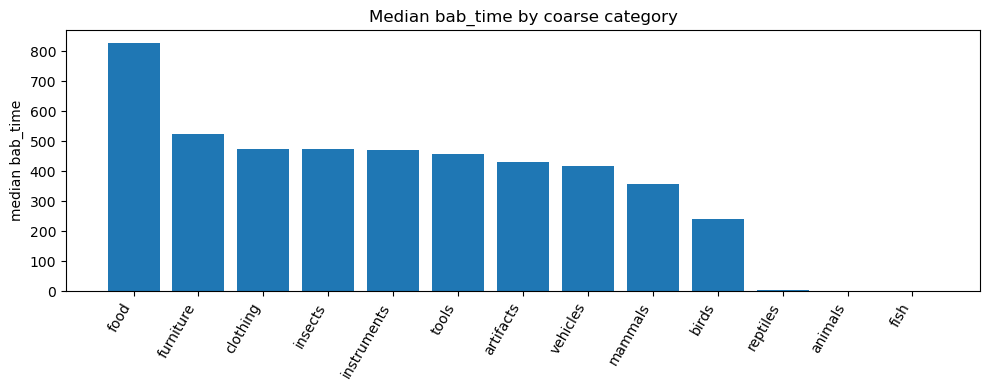

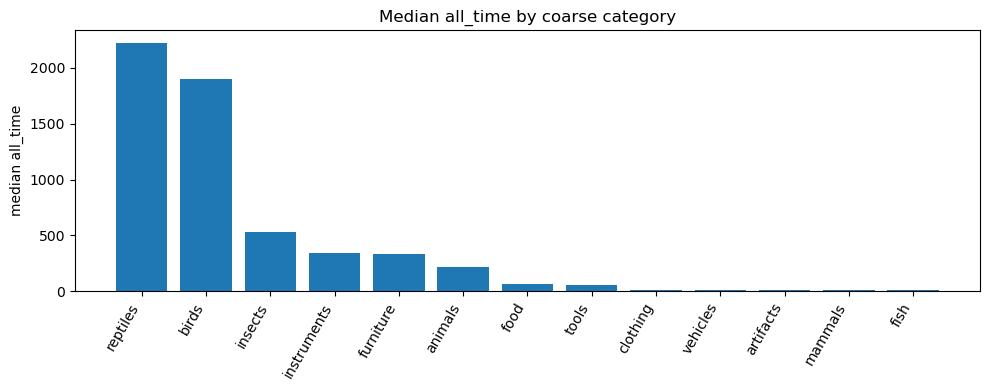

In [111]:
# Plot: median runtime by coarse category (overall)
import matplotlib.pyplot as plt

for tc in avail_time_cols:
    med = (df.dropna(subset=[tc]).groupby("coarse_cat")[tc].median().sort_values(ascending=False))
    plt.figure(figsize=(10, 4))
    plt.bar(med.index.astype(str), med.values)
    plt.xticks(rotation=60, ha="right")
    plt.ylabel(f"median {tc}")
    plt.title(f"Median {tc} by coarse category")
    plt.tight_layout()
    plt.show()

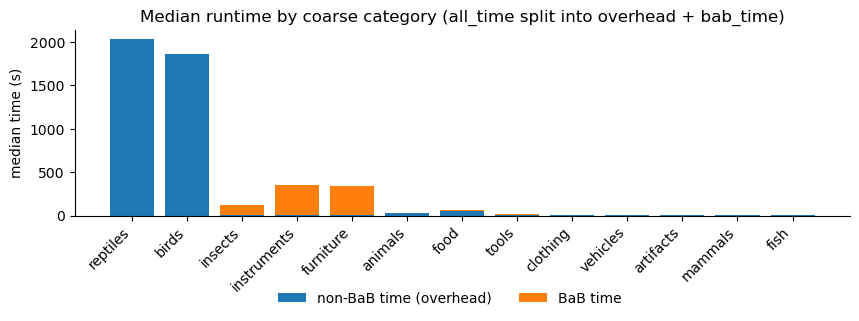

In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Config
# -------------------------
ALL_COL = "all_time"
BAB_COL = "bab_time"

assert ALL_COL in df.columns and BAB_COL in df.columns, "Need all_time and bab_time in df"

# Make numeric
d = df.copy()
d[ALL_COL] = pd.to_numeric(d[ALL_COL], errors="coerce")
d[BAB_COL] = pd.to_numeric(d[BAB_COL], errors="coerce")

# Keep rows with all_time
d = d.dropna(subset=[ALL_COL])

# Define "went to BaB" (adjust if your logging uses 0 instead of NaN)
d["went_bab"] = d[BAB_COL].fillna(0) > 0

# Compute overhead and sanitize
d["bab_time_clean"] = d[BAB_COL].fillna(0)

# overhead = all_time - bab_time, clipped (guards against tiny negative due to logging noise)
d["overhead_time"] = (d[ALL_COL] - d["bab_time_clean"]).clip(lower=0)

# Optional: drop weird rows where bab_time > all_time by a lot (shouldn't happen)
# d = d[d["bab_time_clean"] <= d[ALL_COL] + 1e-6]

# -------------------------
# Aggregate by coarse category
# Choose ONE: median (recommended) or mean
# -------------------------
AGG = "median"  # "mean" also ok

if AGG == "median":
    agg_tbl = d.groupby("coarse_cat")[["overhead_time", "bab_time_clean", ALL_COL]].median()
else:
    agg_tbl = d.groupby("coarse_cat")[["overhead_time", "bab_time_clean", ALL_COL]].mean()

# Sort by total all_time (descending)
agg_tbl = agg_tbl.sort_values(ALL_COL, ascending=False)

# Optional: drop categories with very few samples (paper cleanliness)
MIN_N = 5
counts = d.groupby("coarse_cat").size()
agg_tbl = agg_tbl[counts.reindex(agg_tbl.index).fillna(0) >= MIN_N]

# -------------------------
# Plot (stacked: overhead + bab_time = all_time)
# -------------------------
cats = agg_tbl.index.astype(str).tolist()
x = np.arange(len(cats))

fig, ax = plt.subplots(figsize=(10, 3.2))

over = agg_tbl["overhead_time"].values
bab  = agg_tbl["bab_time_clean"].values

bars1 = ax.bar(cats, over, label="non-BaB time (overhead)")
bars2 = ax.bar(cats, bab, bottom=over, label="BaB time")

ax.set_ylabel(f"{AGG} time (s)")
ax.set_title(f"{AGG.capitalize()} runtime by coarse category (all_time split into overhead + bab_time)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xticks(x)
ax.set_xticklabels(cats, rotation=45, ha="right")

# Legend BELOW the plot (guaranteed)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncols=2, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.subplots_adjust(bottom=0.30)

plt.show()

In [113]:
import pandas as pd
import numpy as np

ALL_COL = "all_time"
BAB_COL = "bab_time"

d = df.copy()
d[ALL_COL] = pd.to_numeric(d[ALL_COL], errors="coerce")
d[BAB_COL] = pd.to_numeric(d[BAB_COL], errors="coerce")

# Keep valid total runtimes
d = d.dropna(subset=[ALL_COL])

# Replace NaN bab_time with 0 (never entered BaB)
d[BAB_COL] = d[BAB_COL].fillna(0)

# --- NORMALIZATION (global, paper-friendly) ---
max_time = d[ALL_COL].max()

d["all_time_norm"] = d[ALL_COL] / max_time
d["bab_time_norm"] = d[BAB_COL] / max_time

# Optional: drop tiny categories
MIN_N = 5
valid_cats = d["coarse_cat"].value_counts()
valid_cats = valid_cats[valid_cats >= MIN_N].index
d = d[d["coarse_cat"].isin(valid_cats)]

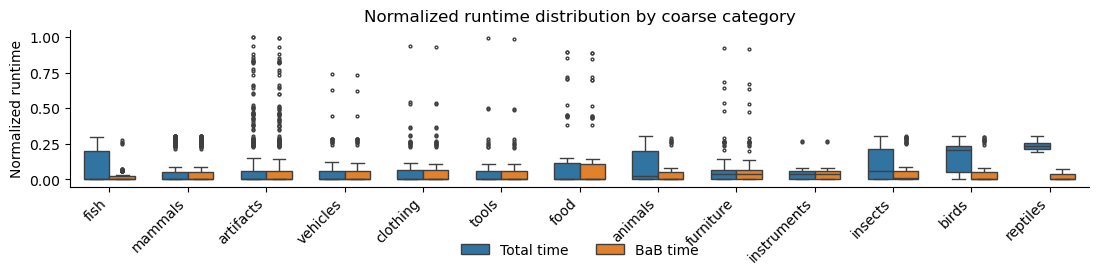

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns

# Order categories by median ALL_TIME (slowest on the right)
order = (
    d.groupby("coarse_cat")["all_time_norm"]
     .median()
     .sort_values()
     .index
)

# Long-form for seaborn
plot_df = pd.melt(
    d,
    id_vars=["coarse_cat"],
    value_vars=["all_time_norm", "bab_time_norm"],
    var_name="time_type",
    value_name="norm_time"
)

plot_df["time_type"] = plot_df["time_type"].map({
    "all_time_norm": "Total time",
    "bab_time_norm": "BaB time"
})



plt.figure(figsize=(11, 3.6))

sns.boxplot(
    data=plot_df,
    x="coarse_cat",
    y="norm_time",
    hue="time_type",
    order=order,
    width=0.65,
    fliersize=2
)

plt.ylabel("Normalized runtime")
plt.xlabel("")
plt.title("Normalized runtime distribution by coarse category")

plt.xticks(rotation=45, ha="right")

# Clean paper look
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend BELOW
handles, labels = ax.get_legend_handles_labels()
plt.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.28),
    ncol=2,
    frameon=False
)

plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.show()

## D) Optional: compare *variants* inside each coarse category

If your CSV contains a `tag` column (common in your pipeline), we will summarize outcomes and time by `(coarse_cat, tag)`.

This helps answer questions like:
- Are *object* segments systematically harder than *background* **within the same semantic class family**?

In [118]:
TAG_COL = "tag" if "tag" in df.columns else None
TAG_COL

'tag'

In [119]:
if TAG_COL is None:
    print("No 'tag' column found. Skipping variant-by-tag analysis.")
else:
    # Outcome distribution per (coarse_cat, tag)
    tag_counts = (df.groupby(["coarse_cat", TAG_COL, "result_cat"])
                    .size()
                    .rename("n")
                    .reset_index())
    tag_tot = tag_counts.groupby(["coarse_cat", TAG_COL])["n"].sum().rename("total").reset_index()
    tag_counts = tag_counts.merge(tag_tot, on=["coarse_cat", TAG_COL], how="left")
    tag_counts["pct"] = tag_counts["n"] / tag_counts["total"]

    display(tag_counts.sort_values(["coarse_cat", TAG_COL, "pct"], ascending=[True, True, False]).head(25))

    # Runtime medians per (coarse_cat, tag, result_cat)
    for tc in avail_time_cols:
        rt = (df.dropna(subset=[tc])
                .groupby(["coarse_cat", TAG_COL, "result_cat"])[tc]
                .median()
                .rename("median_time")
                .reset_index()
             )
        print("\nMedian", tc, "by (coarse_cat, tag, result):")
        display(rt.sort_values(["coarse_cat", TAG_COL, "median_time"], ascending=[True, True, False]).head(25))

,coarse_cat,tag,result_cat,n,total,pct
0,animals,n01629819_European_fire_salamander_global,unsafe (counterexample),4,4,1.00
1,animals,n01629819_European_fire_salamander_seg0_fixmask,unsafe (counterexample),4,4,1.00
2,animals,n01629819_European_fire_salamander_seg0_fixnon...,unsafe (counterexample),4,4,1.00
3,animals,n01631663_eft_global,unsafe (counterexample),4,4,1.00
4,animals,n01631663_eft_seg0_fixmask,unsafe (counterexample),4,4,1.00
5,animals,n01631663_eft_seg0_fixnonmask,unsafe (counterexample),4,4,1.00
6,animals,n01632458_spotted_salamander_global,unsafe (counterexample),4,4,1.00
7,animals,n01632458_spotted_salamander_seg0_fixmask,unsafe (counterexample),4,4,1.00
8,animals,n01632458_spotted_salamander_seg0_fixnonmask,unsafe (counterexample),4,4,1.00
9,animals,n01641577_bullfrog_global,unsafe (counterexample),4,4,1.00



Median bab_time by (coarse_cat, tag, result):


,coarse_cat,tag,result_cat,median_time
0,animals,n01629819_European_fire_salamander_global,unsafe (counterexample),1.918366
1,animals,n01629819_European_fire_salamander_seg0_fixmask,unsafe (counterexample),2.053144
2,animals,n01629819_European_fire_salamander_seg0_fixnon...,unsafe (counterexample),2.114415
3,animals,n01631663_eft_global,unsafe (counterexample),2.015646
4,animals,n01631663_eft_seg0_fixmask,unsafe (counterexample),1.981566
5,animals,n01631663_eft_seg0_fixnonmask,unsafe (counterexample),1.516816
6,animals,n01632458_spotted_salamander_global,unsafe (counterexample),2.110628
7,animals,n01632458_spotted_salamander_seg0_fixmask,unsafe (counterexample),1.975444
8,animals,n01632458_spotted_salamander_seg0_fixnonmask,unsafe (counterexample),1.969990
9,animals,n01641577_bullfrog_global,unsafe (counterexample),2.065955



Median all_time by (coarse_cat, tag, result):


,coarse_cat,tag,result_cat,median_time
0,animals,n01629819_European_fire_salamander_global,unsafe (counterexample),2051.247983
1,animals,n01629819_European_fire_salamander_seg0_fixmask,unsafe (counterexample),2049.488142
2,animals,n01629819_European_fire_salamander_seg0_fixnon...,unsafe (counterexample),1857.598799
3,animals,n01631663_eft_global,unsafe (counterexample),2048.139689
4,animals,n01631663_eft_seg0_fixmask,unsafe (counterexample),1880.461111
5,animals,n01631663_eft_seg0_fixnonmask,unsafe (counterexample),2163.942148
6,animals,n01632458_spotted_salamander_global,unsafe (counterexample),2046.168011
7,animals,n01632458_spotted_salamander_seg0_fixmask,unsafe (counterexample),2049.415085
8,animals,n01632458_spotted_salamander_seg0_fixnonmask,unsafe (counterexample),2242.240478
9,animals,n01641577_bullfrog_global,unsafe (counterexample),2056.034317


## E) Export: category-level summary CSVs

This writes clean tables you can paste into the paper:
- `coarse_outcome_pct.csv`
- `coarse_runtime_summary_<timecol>.csv`

In [120]:
OUT_DIR = Path("analysis_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

pivot_pct.to_csv(OUT_DIR / "coarse_outcome_pct.csv")

for tc, s in summaries.items():
    s.to_csv(OUT_DIR / f"coarse_runtime_summary_{tc}.csv", index=False)

print("Wrote:", list(OUT_DIR.iterdir()))

Wrote: [PosixPath('analysis_outputs/coarse_runtime_summary_all_time.csv'), PosixPath('analysis_outputs/coarse_runtime_summary_bab_time.csv'), PosixPath('analysis_outputs/coarse_outcome_pct.csv')]


## C2) Result summaries by coarse category (same style as runtime)

This mirrors **Part C (runtime)** but for **verification outcomes**.
We aggregate results per coarse semantic category and visualize them
both as **counts** and **normalized proportions**.

Outcome mapping:
- **safe** → UNSAT (verified)
- **unsafe (counterexample)** → SAT
- **unknown (timeout)** → TIMEOUT

In [121]:
# ============================
# Result summary tables
# ============================

# Count table
result_counts = (
    df.groupby(["coarse_cat", "result_cat"])
      .size()
      .rename("n")
      .reset_index()
)

# Total per category
totals = (
    result_counts.groupby("coarse_cat")["n"]
    .sum()
    .rename("total")
    .reset_index()
)

result_counts = result_counts.merge(totals, on="coarse_cat", how="left")
result_counts["pct"] = result_counts["n"] / result_counts["total"]

result_counts.sort_values(["coarse_cat", "n"], ascending=[True, False]).head(20)

,coarse_cat,result_cat,n,total,pct
3,animals,unsafe (counterexample),204,336,0.607143
1,animals,safe,91,336,0.270833
2,animals,unknown (timeout),39,336,0.116071
0,animals,other,2,336,0.005952
6,artifacts,unknown (timeout),2253,3228,0.697955
7,artifacts,unsafe (counterexample),596,3228,0.184634
5,artifacts,safe,371,3228,0.114932
4,artifacts,other,8,3228,0.002478
11,birds,unsafe (counterexample),345,672,0.513393
9,birds,safe,206,672,0.306548


In [122]:
# Pivot tables (same spirit as runtime summaries)

result_count_pivot = (
    result_counts
    .pivot_table(
        index="coarse_cat",
        columns="result_cat",
        values="n",
        fill_value=0
    )
    .sort_index()
)

result_pct_pivot = (
    result_counts
    .pivot_table(
        index="coarse_cat",
        columns="result_cat",
        values="pct",
        fill_value=0.0
    )
    .sort_index()
)

display(result_count_pivot)
display(result_pct_pivot)

result_cat,other,safe,unknown (timeout),unsafe (counterexample)
coarse_cat,,,,
animals,2.0,91.0,39.0,204.0
artifacts,8.0,371.0,2253.0,596.0
birds,3.0,206.0,118.0,345.0
clothing,4.0,78.0,325.0,97.0
communication,0.0,0.0,60.0,0.0
fish,1.0,40.0,19.0,108.0
food,0.0,30.0,450.0,48.0
furniture,3.0,64.0,105.0,56.0
insects,9.0,144.0,61.0,158.0


result_cat,other,safe,unknown (timeout),unsafe (counterexample)
coarse_cat,,,,
animals,0.005952,0.270833,0.116071,0.607143
artifacts,0.002478,0.114932,0.697955,0.184634
birds,0.004464,0.306548,0.175595,0.513393
clothing,0.007937,0.154762,0.644841,0.192460
communication,0.000000,0.000000,1.000000,0.000000
fish,0.005952,0.238095,0.113095,0.642857
food,0.000000,0.056818,0.852273,0.090909
furniture,0.013158,0.280702,0.460526,0.245614
insects,0.024194,0.387097,0.163978,0.424731


/var/folders/fr/3yg6c3f55w58dtlsnjcqjmth0000gq/T/ipykernel_2291/3717831533.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(result_count_pivot.index.astype(str), rotation=60, ha="right")


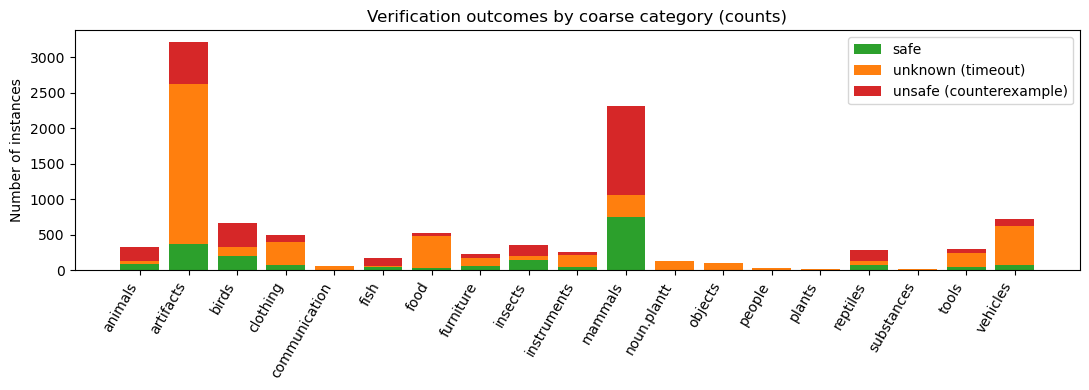

/var/folders/fr/3yg6c3f55w58dtlsnjcqjmth0000gq/T/ipykernel_2291/3717831533.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(result_pct_pivot.index.astype(str), rotation=60, ha="right")


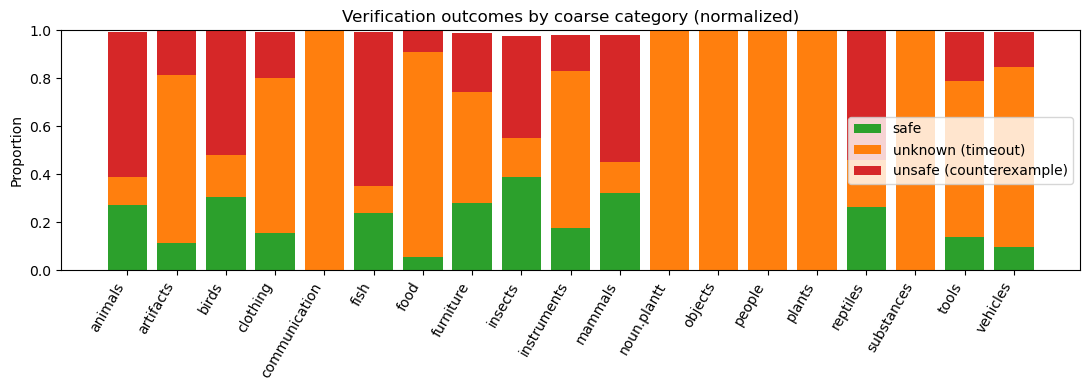

In [123]:
# ============================
# Plots: result distribution by coarse category
# ============================
import matplotlib.pyplot as plt

ORDER = ["safe", "unknown (timeout)", "unsafe (counterexample)"]
COLOR = {
    "safe": "#2ca02c",
    "unsafe (counterexample)": "#d62728",
    "unknown (timeout)": "#ff7f0e",
}

# --- Absolute counts
fig, ax = plt.subplots(figsize=(11, 4))
bottom = None

for r in ORDER:
    if r not in result_count_pivot.columns:
        continue
    vals = result_count_pivot[r].values
    ax.bar(
        result_count_pivot.index.astype(str),
        vals,
        bottom=bottom,
        label=r,
        color=COLOR.get(r)
    )
    bottom = vals if bottom is None else bottom + vals

ax.set_ylabel("Number of instances")
ax.set_title("Verification outcomes by coarse category (counts)")
ax.legend()
ax.set_xticklabels(result_count_pivot.index.astype(str), rotation=60, ha="right")
plt.tight_layout()
plt.show()

# --- Normalized proportions
fig, ax = plt.subplots(figsize=(11, 4))
bottom = None

for r in ORDER:
    if r not in result_pct_pivot.columns:
        continue
    vals = result_pct_pivot[r].values
    ax.bar(
        result_pct_pivot.index.astype(str),
        vals,
        bottom=bottom,
        label=r,
        color=COLOR.get(r)
    )
    bottom = vals if bottom is None else bottom + vals

ax.set_ylabel("Proportion")
ax.set_ylim(0, 1.0)
ax.set_title("Verification outcomes by coarse category (normalized)")
ax.legend()
ax.set_xticklabels(result_pct_pivot.index.astype(str), rotation=60, ha="right")
plt.tight_layout()
plt.show()

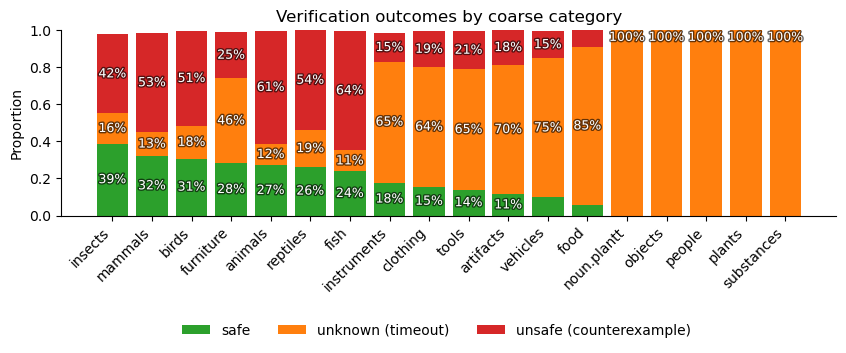

In [124]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

ORDER = ["safe", "unknown (timeout)", "unsafe (counterexample)"]
COLOR = {
    "safe": "#2ca02c",
    "unknown (timeout)": "#ff7f0e",
    "unsafe (counterexample)": "#d62728",
}

LABEL_MIN = 0.10  # label only segments >= 10% (paper-friendly)

# --- start from the normalized pivot (proportions) ---
plot_df = result_pct_pivot.copy()

# 1) Drop "communication"
plot_df = plot_df[~plot_df.index.astype(str).str.contains("communication", case=False, na=False)]

# 2) Sort by SAFE proportion
if "safe" in plot_df.columns:
    plot_df = plot_df.sort_values("safe", ascending=False)
else:
    plot_df = plot_df.sort_index()

cats = plot_df.index.astype(str).tolist()
x = np.arange(len(cats))

# 3) Paper-style figure size
fig, ax = plt.subplots(figsize=(10, 3.2))

bottom = np.zeros(len(cats), dtype=float)

# Helper: readable label style (white text + outline)
def add_label(ax, x, y, s, fs=9):
    t = ax.text(x, y, s, ha="center", va="center", fontsize=fs, color="white")
    t.set_path_effects([pe.withStroke(linewidth=2, foreground="black", alpha=0.6)])

# Detect "pure" bars (≈100% one class) and label only once at top
rowmax = plot_df.max(axis=1).values
is_pure = rowmax >= 0.999  # numerical tolerance

for r in ORDER:
    if r not in plot_df.columns:
        continue
    vals = plot_df[r].values
    bars = ax.bar(cats, vals, bottom=bottom, label=r, color=COLOR.get(r))

    for i, (b, v, bt) in enumerate(zip(bars, vals, bottom)):
        if v <= 0:
            continue

        # If bar is pure, skip segment labels (we'll add one top label later)
        if is_pure[i]:
            continue

        # Only label sufficiently large segments
        if v >= LABEL_MIN:
            add_label(
                ax,
                b.get_x() + b.get_width() / 2.0,
                bt + v / 2.0,
                f"{v*100:.0f}%",
                fs=9
            )

    bottom += vals

# Add one top label for pure bars (e.g., 100% timeout)
for i, cat in enumerate(cats):
    if is_pure[i]:
        add_label(ax, i, 0.96, "100%", fs=9)  # near top, readable

# Axes styling (paper)
ax.set_ylabel("Proportion")
ax.set_ylim(0, 1.0)
ax.set_title("Verification outcomes by coarse category")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Better x labels
ax.set_xticks(x)
ax.set_xticklabels(cats, rotation=45, ha="right")




# Put legend BELOW the plot (on the FIGURE), not on the axes
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncols=3,
    frameon=False,
    bbox_to_anchor=(0.5, -0.12)  # move down/up with this
)

# Reserve space at the bottom for the legend (key!)
fig.subplots_adjust(bottom=0.30)

plt.show()

In [96]:
def infer_semantic_variant(df: pd.DataFrame):
    out = df.copy()

    tag = out["tag"].astype(str).str.lower()

    out["variant"] = "Other"

    # Global
    if "is_global" in out.columns:
        out.loc[out["is_global"] == True, "variant"] = "Global"
    out.loc[tag.str.contains("global"), "variant"] = "Global"

    # Object-only perturbation (mask) → background fixed
    out.loc[
        tag.str.contains(r"fix[_\-]?non[_\-]?mask", regex=True),
        "variant"
    ] = "Object"

    # Background-only perturbation (non-mask) → object fixed
    out.loc[
        tag.str.contains(r"fix[_\-]?mask", regex=True)
        & ~tag.str.contains(r"fix[_\-]?non[_\-]?mask", regex=True),
        "variant"
    ] = "Background"

    return out

In [97]:
df_v = infer_semantic_variant(df)

# Keep only the three meaningful variants
df_v = df_v[df_v["variant"].isin(["Global", "Object", "Background"])].copy()

grp = (
    df_v
    .groupby(["eps", "k", "variant", "result_cat"])
    .size()
    .rename("n")
    .reset_index()
)

tot = (
    grp
    .groupby(["eps", "k", "variant"])["n"]
    .sum()
    .rename("total")
    .reset_index()
)

grp = grp.merge(tot, on=["eps", "k", "variant"], how="left")
grp["pct"] = grp["n"] / grp["total"]

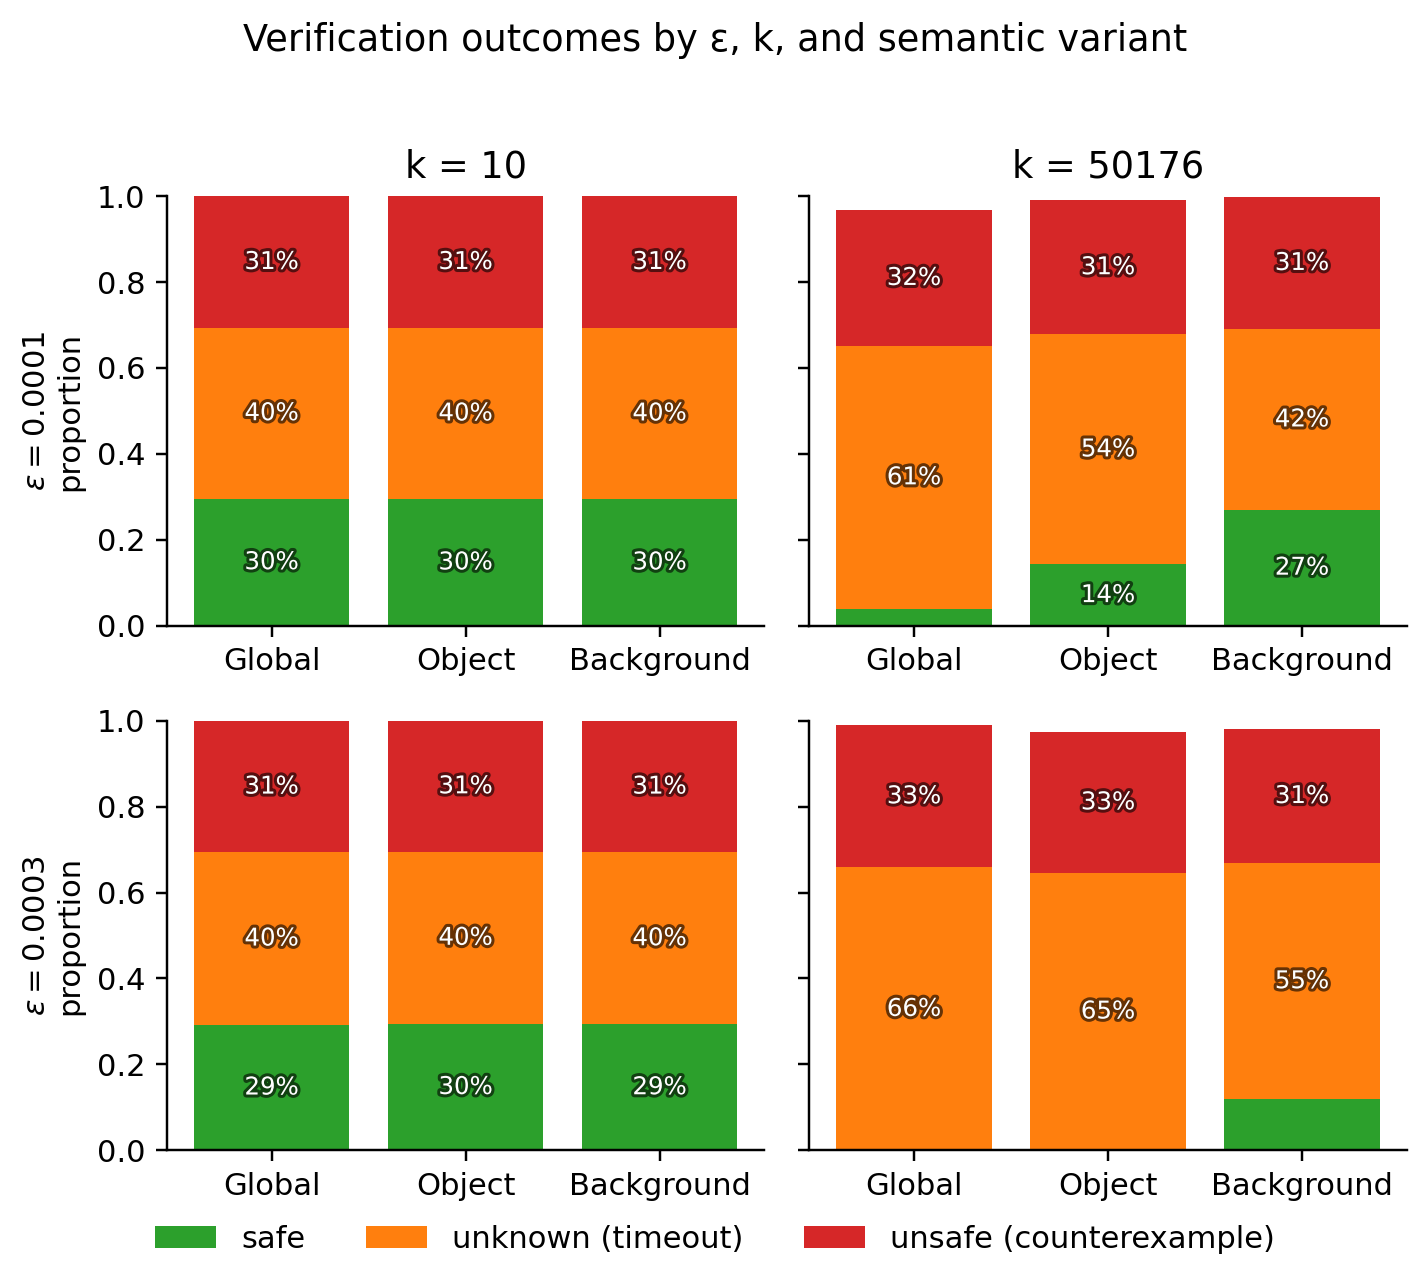

In [98]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

ORDER = ["safe", "unknown (timeout)", "unsafe (counterexample)"]
COLOR = {
    "safe": "#2ca02c",
    "unknown (timeout)": "#ff7f0e",
    "unsafe (counterexample)": "#d62728",
}

VARIANTS = ["Global", "Object", "Background"]
LABEL_MIN = 0.12

eps_vals = sorted(grp["eps"].unique())
k_vals   = sorted(grp["k"].unique())

rows = len(eps_vals)
cols = len(k_vals)

fig, axes = plt.subplots(
    rows, cols,
    figsize=(cols * 3.3, rows * 2.7),
    sharey=True,
    dpi=220
)

if rows == 1 and cols == 1:
    axes = np.array([[axes]])
elif rows == 1 or cols == 1:
    axes = np.atleast_2d(axes)

def add_label(ax, x, y, s):
    t = ax.text(x, y, s, ha="center", va="center", fontsize=8, color="white")
    t.set_path_effects([pe.withStroke(linewidth=2, foreground="black", alpha=0.6)])

for i, eps in enumerate(eps_vals):
    for j, k in enumerate(k_vals):
        ax = axes[i, j]

        sub = grp[(grp["eps"] == eps) & (grp["k"] == k)]

        bottoms = np.zeros(len(VARIANTS))

        for r in ORDER:
            vals = []
            for v in VARIANTS:
                row = sub[(sub["variant"] == v) & (sub["result_cat"] == r)]
                vals.append(row["pct"].iloc[0] if len(row) else 0.0)

            bars = ax.bar(
                VARIANTS, vals,
                bottom=bottoms,
                color=COLOR[r],
                label=r if (i == 0 and j == 0) else None
            )

            for b, v, bt in zip(bars, vals, bottoms):
                if v >= LABEL_MIN:
                    add_label(
                        ax,
                        b.get_x() + b.get_width() / 2,
                        bt + v / 2,
                        f"{v*100:.0f}%"
                    )

            bottoms += np.array(vals)

        # Titles / labels
        if i == 0:
            ax.set_title(f"k = {int(k)}")
        if j == 0:
            ax.set_ylabel(rf"$\epsilon={eps:g}$" + "\nproportion")

        ax.set_ylim(0, 1.0)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

# Legend BELOW (figure-level)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, -0.04)
)

fig.suptitle("Verification outcomes by ε, k, and semantic variant", y=1.02)
fig.subplots_adjust(bottom=0.18)
plt.tight_layout()
plt.show()

**How to read this (paper-friendly):**

- Categories with a higher **safe proportion** are semantically easier to certify.
- Categories dominated by **timeouts** indicate structurally hard instances.
- A shift from *safe → timeout → unsafe* across categories mirrors the
  runtime trends in Part C, but from an outcome perspective.

In [126]:
# df must already contain: eps, k, tag, result_cat, coarse_cat
df_v = infer_semantic_variant(df)
df_v = df_v[df_v["variant"].isin(["Global", "Object", "Background"])].copy()

In [132]:
# -------------------------
# 3) Plot: grouped stacked bars (NO percentages)
# -------------------------
bar_w = 0.22
gap = 0.12  # gap between category groups
cats_sorted = df["coarse_cat"]

n_cat = len(cats_sorted)
x0 = np.arange(n_cat) * (3*bar_w + gap)

fig, ax = plt.subplots(figsize=(max(12, n_cat * 0.55), 3.6), dpi=220)

variant_offsets = {
    "Global": -bar_w,
    "Object": 0.0,
    "Background": +bar_w
}

for v in VARIANTS:
    vals_mat = np.vstack([
        pivot.loc[(cat, v)].values if (cat, v) in pivot.index else np.zeros(len(ORDER))
        for cat in cats_sorted
    ])

    bottoms = np.zeros(n_cat)

    for idx_r, r in enumerate(ORDER):
        vals = vals_mat[:, idx_r]
        xs = x0 + variant_offsets[v]

        ax.bar(
            xs, vals,
            width=bar_w,
            bottom=bottoms,
            color=COLOR[r],
            label=r if v == VARIANTS[0] else None
        )

        bottoms += vals

# X ticks at group centers
ax.set_xticks(x0)
ax.set_xticklabels(cats_sorted, rotation=45, ha="right")
ax.tick_params(axis="x", pad=18)

ax.set_ylim(0, 1.0)
ax.set_ylabel("Proportion")
ax.set_title(
    "Verification outcomes by coarse category (sorted by safe)\n"
    "Global (G) vs Object (O) vs Background (B)"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Sub-labels for variants (G / O / B)
for i in range(n_cat):
    ax.text(x0[i] - bar_w, -0.035, "G", ha="center", va="top", fontsize=9,
            transform=ax.get_xaxis_transform())
    ax.text(x0[i],         -0.035, "O", ha="center", va="top", fontsize=9,
            transform=ax.get_xaxis_transform())
    ax.text(x0[i] + bar_w, -0.035, "B", ha="center", va="top", fontsize=9,
            transform=ax.get_xaxis_transform())

# Legend below
handles = [plt.Rectangle((0,0),1,1,color=COLOR[r]) for r in ORDER]
fig.legend(
    handles, ORDER,
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, -0.10)   # was -0.02
)

fig.subplots_adjust(bottom=0.34)  # was ~0.25


plt.show()